## Data Analysis

> Colab link: https://colab.research.google.com/drive/1iWn4q-t2uFoaOpHtRWhnY3iVc4ApVRCZ?usp=sharing

> data link: https://drive.google.com/drive/folders/10ifViUBrmseUgiffP-9V4giJbjp4p8Uz

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [ ]:
if 'google.colab' in str(get_ipython()):
  from google.colab import drive
  drive.mount('/content/drive')
  BASE_DIR='/content/drive/MyDrive/Data For AutoScaling'
else:
  BASE_DIR='./'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path_train = os.path.join(BASE_DIR, 'train.csv')
path_test  = os.path.join(BASE_DIR, 'test.csv')

**I.Xem qua về dữ liệu**







In [ ]:
df_train_preview = pd.read_csv(path_train, nrows=5)
display(df_train_preview)
print('THÔNG TIN CÁC CỘT')
print(df_train_preview.info())

,request_src,timestamp,method,dest_path,http_type,status,bytes
0,199.72.81.55,01/Jul/1995:00:00:01 -0400,GET,/history/apollo/,HTTP/1.0,200,6245
1,unicomp6.unicomp.net,01/Jul/1995:00:00:06 -0400,GET,/shuttle/countdown/,HTTP/1.0,200,3985
2,199.120.110.21,01/Jul/1995:00:00:09 -0400,GET,/shuttle/missions/sts-73/mission-sts-73.html,HTTP/1.0,200,4085
3,burger.letters.com,01/Jul/1995:00:00:11 -0400,GET,/shuttle/countdown/liftoff.html,HTTP/1.0,304,0
4,199.120.110.21,01/Jul/1995:00:00:11 -0400,GET,/shuttle/missions/sts-73/sts-73-patch-small.gif,HTTP/1.0,200,4179


THÔNG TIN CÁC CỘT
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   request_src  5 non-null      object
 1   timestamp    5 non-null      object
 2   method       5 non-null      object
 3   dest_path    5 non-null      object
 4   http_type    5 non-null      object
 5   status       5 non-null      int64 
 6   bytes        5 non-null      int64 
dtypes: int64(2), object(5)
memory usage: 412.0+ bytes
None


In [ ]:
df_test_preview = pd.read_csv(path_test, nrows=5)
display(df_test_preview)
print(df_test_preview.info)

,request_src,timestamp,method,dest_path,http_type,status,bytes
0,ix-mia1-02.ix.netcom.com,23/Aug/1995:00:00:00 -0400,GET,/ksc.html,HTTP/1.0,200,7087
1,internet-gw.watson.ibm.com,23/Aug/1995:00:00:05 -0400,GET,/history/apollo/pad-abort-test-2/pad-abort-tes...,HTTP/1.0,200,1292
2,ix-mia1-02.ix.netcom.com,23/Aug/1995:00:00:06 -0400,GET,/images/ksclogo-medium.gif,HTTP/1.0,200,5866
3,internet-gw.watson.ibm.com,23/Aug/1995:00:00:08 -0400,GET,/history/apollo/pad-abort-test-2/pad-abort-tes...,HTTP/1.0,200,1625
4,internet-gw.watson.ibm.com,23/Aug/1995:00:00:10 -0400,GET,/history/apollo/pad-abort-test-2/pad-abort-tes...,HTTP/1.0,404,0


<bound method DataFrame.info of                   request_src                   timestamp method  \
0    ix-mia1-02.ix.netcom.com  23/Aug/1995:00:00:00 -0400    GET   
1  internet-gw.watson.ibm.com  23/Aug/1995:00:00:05 -0400    GET   
2    ix-mia1-02.ix.netcom.com  23/Aug/1995:00:00:06 -0400    GET   
3  internet-gw.watson.ibm.com  23/Aug/1995:00:00:08 -0400    GET   
4  internet-gw.watson.ibm.com  23/Aug/1995:00:00:10 -0400    GET   

                                           dest_path http_type  status  bytes  
0                                          /ksc.html  HTTP/1.0     200   7087  
1  /history/apollo/pad-abort-test-2/pad-abort-tes...  HTTP/1.0     200   1292  
2                         /images/ksclogo-medium.gif  HTTP/1.0     200   5866  
3  /history/apollo/pad-abort-test-2/pad-abort-tes...  HTTP/1.0     200   1625  
4  /history/apollo/pad-abort-test-2/pad-abort-tes...  HTTP/1.0     404      0  >


**II.Xử lí múi giờ ở timestamp**

Dữ liệu ban đầu

In [ ]:
df_train = pd.read_csv(path_train)
print(df_train['timestamp'])

0          01/Jul/1995:00:00:01 -0400
1          01/Jul/1995:00:00:06 -0400
2          01/Jul/1995:00:00:09 -0400
3          01/Jul/1995:00:00:11 -0400
4          01/Jul/1995:00:00:11 -0400
                      ...            
2934956    22/Aug/1995:23:59:55 -0400
2934957    22/Aug/1995:23:59:57 -0400
2934958    22/Aug/1995:23:59:57 -0400
2934959    22/Aug/1995:23:59:58 -0400
2934960    22/Aug/1995:23:59:59 -0400
Name: timestamp, Length: 2934961, dtype: object


In [ ]:
df_test = pd.read_csv(path_test)
print(df_test['timestamp'])

0         23/Aug/1995:00:00:00 -0400
1         23/Aug/1995:00:00:05 -0400
2         23/Aug/1995:00:00:06 -0400
3         23/Aug/1995:00:00:08 -0400
4         23/Aug/1995:00:00:10 -0400
                     ...            
526646    31/Aug/1995:23:59:49 -0400
526647    31/Aug/1995:23:59:49 -0400
526648    31/Aug/1995:23:59:52 -0400
526649    31/Aug/1995:23:59:52 -0400
526650    31/Aug/1995:23:59:53 -0400
Name: timestamp, Length: 526651, dtype: object


In [ ]:
def process_datetime_features(df):
    df['timestamp'] = pd.to_datetime(df['timestamp'], format="%d/%b/%Y:%H:%M:%S %z", errors='coerce')


    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

    return df


df_train = process_datetime_features(df_train)
df_test = process_datetime_features(df_test)

print(df_train['timestamp'].min(), "->", df_train['timestamp'].max())
print(df_test['timestamp'].min(), "->", df_test['timestamp'].max())

1995-07-01 00:00:01-04:00 -> 1995-08-22 23:59:59-04:00
1995-08-23 00:00:00-04:00 -> 1995-08-31 23:59:53-04:00


In [ ]:
def aggregate_data(df, time_granularity='h'):

    df_agg = df.set_index('timestamp')

    df_resampled = df_agg.resample(time_granularity).agg({
        'request_src': 'count',
        'bytes': 'sum'
    }).rename(columns={'request_src': 'request_count', 'bytes': 'bytes_sum'})


    df_resampled = df_resampled.fillna(0)


    df_resampled['hour'] = df_resampled.index.hour
    df_resampled['day_of_week'] = df_resampled.index.dayofweek
    df_resampled['is_weekend'] = df_resampled.index.dayofweek.isin([5, 6]).astype(int)

    return df_resampled


ts_train = aggregate_data(df_train)
ts_test = aggregate_data(df_test)

print(ts_train.shape)
print(ts_train.head())

(1272, 5)
                           request_count  bytes_sum  hour  day_of_week  \
timestamp                                                                
1995-07-01 00:00:00-04:00           3565   80985486     0            5   
1995-07-01 01:00:00-04:00           3004   81572855     1            5   
1995-07-01 02:00:00-04:00           2268   57160621     2            5   
1995-07-01 03:00:00-04:00           1734   37293218     3            5   
1995-07-01 04:00:00-04:00           1482   29319770     4            5   

                           is_weekend  
timestamp                              
1995-07-01 00:00:00-04:00           1  
1995-07-01 01:00:00-04:00           1  
1995-07-01 02:00:00-04:00           1  
1995-07-01 03:00:00-04:00           1  
1995-07-01 04:00:00-04:00           1  


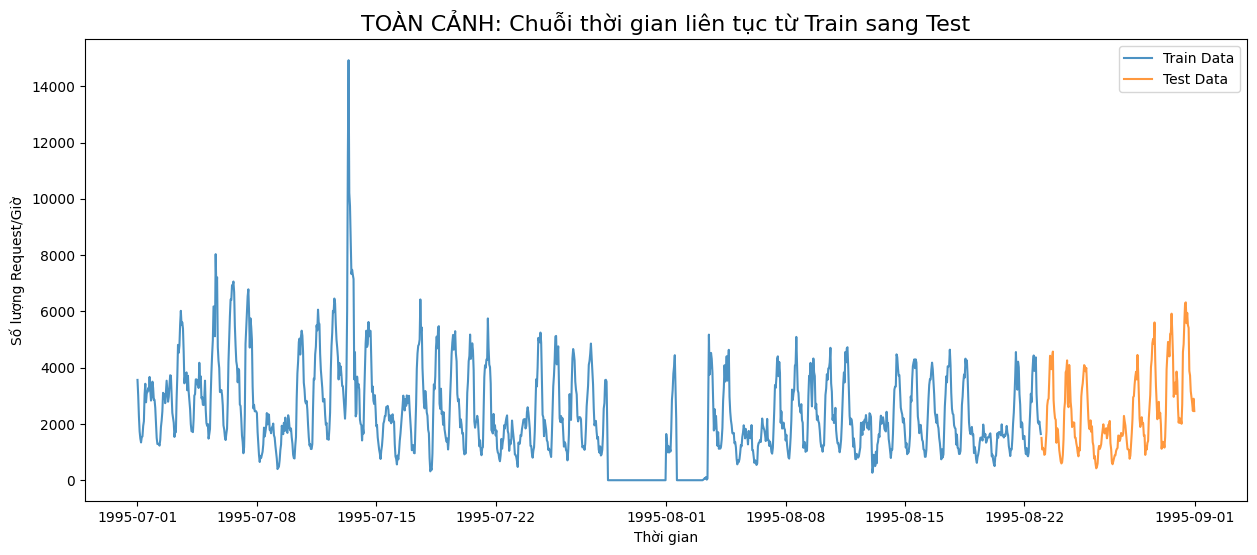

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(ts_train.index, ts_train['request_count'], label='Train Data', color='#1f77b4', alpha=0.8)
plt.plot(ts_test.index, ts_test['request_count'], label='Test Data', color='#ff7f0e', alpha=0.8)

plt.title('TOÀN CẢNH: Chuỗi thời gian liên tục từ Train sang Test', fontsize=16)
plt.xlabel('Thời gian')
plt.ylabel('Số lượng Request/Giờ')
plt.legend()
plt.show()

/tmp/ipython-input-182302775.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=week_days, y=weekly_profile.values, ax=axes[1], palette="viridis")


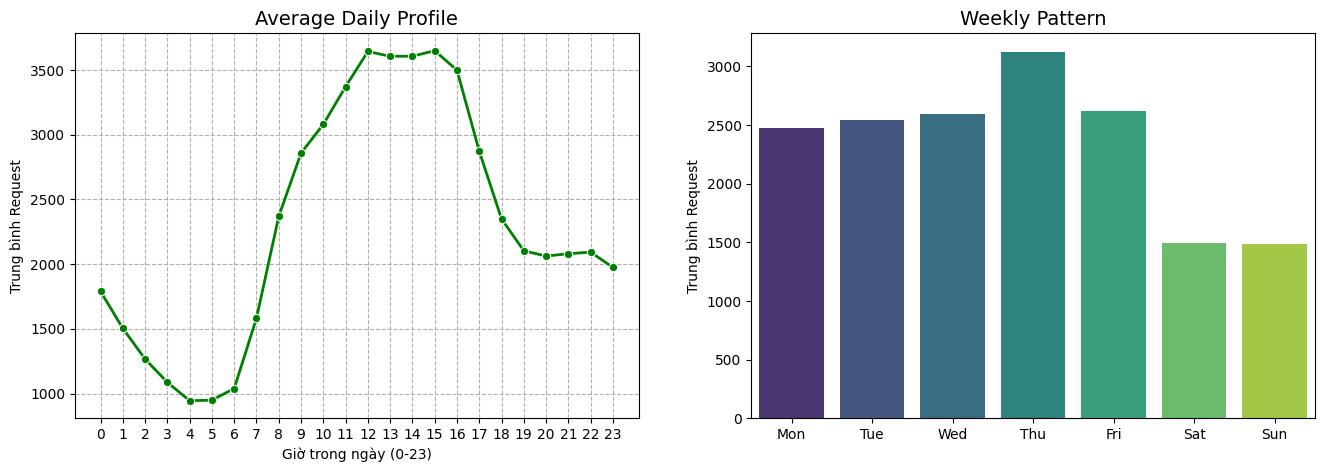

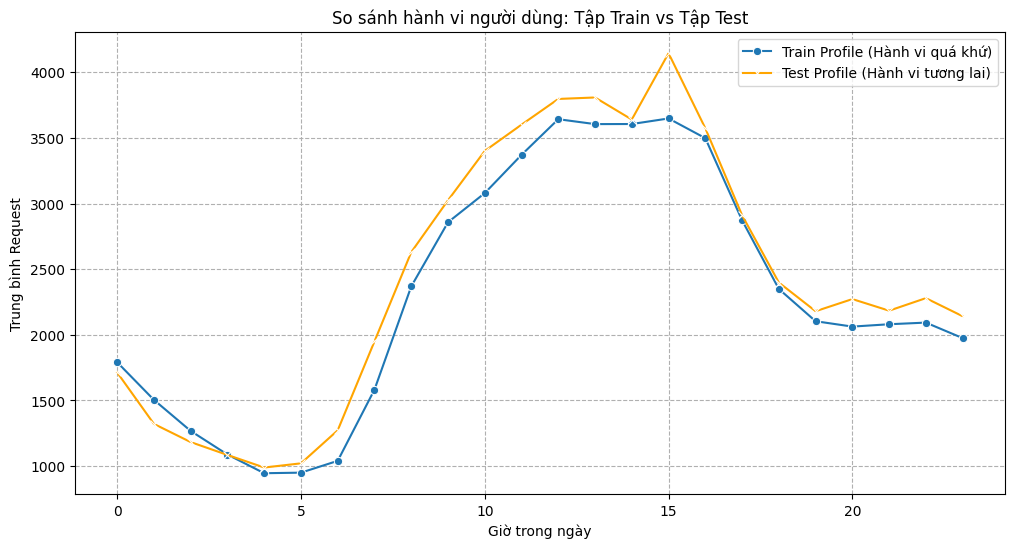

<Figure size 640x480 with 0 Axes>

In [ ]:

hourly_profile = ts_train.groupby('hour')['request_count'].mean()


weekly_profile = ts_train.groupby('day_of_week')['request_count'].mean()
week_days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(x=hourly_profile.index, y=hourly_profile.values, ax=axes[0], marker='o', linewidth=2, color='green')
axes[0].set_title('Average Daily Profile', fontsize=14)
axes[0].set_xticks(range(0, 24))
axes[0].set_xlabel('Giờ trong ngày (0-23)')
axes[0].set_ylabel('Trung bình Request')
axes[0].grid(True, linestyle='--')


sns.barplot(x=week_days, y=weekly_profile.values, ax=axes[1], palette="viridis")
axes[1].set_title('Weekly Pattern', fontsize=14)
axes[1].set_ylabel('Trung bình Request')

test_hourly_profile = ts_test.groupby('hour')['request_count'].mean()

plt.figure(figsize=(12, 6))


sns.lineplot(x=hourly_profile.index, y=hourly_profile.values, label='Train Profile (Hành vi quá khứ)', marker='o')

sns.lineplot(x=test_hourly_profile.index, y=test_hourly_profile.values, label='Test Profile (Hành vi tương lai)', marker='x', color='orange')

plt.title('So sánh hành vi người dùng: Tập Train vs Tập Test')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Trung bình Request')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()
plt.tight_layout()
plt.show()

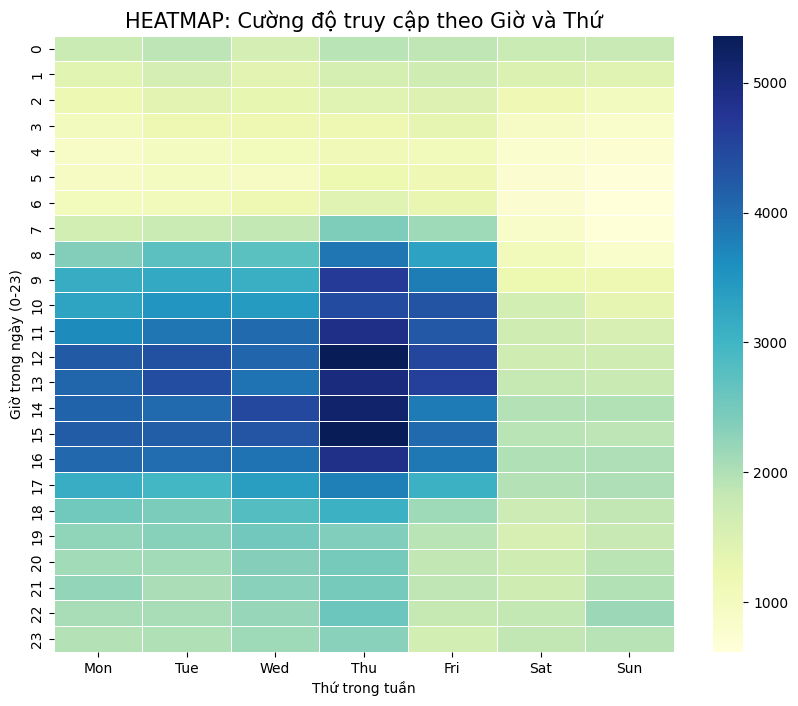

In [ ]:
pivot_table = ts_train.pivot_table(index='hour', columns='day_of_week', values='request_count', aggfunc='mean')

days_map = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
pivot_table.rename(columns=days_map, inplace=True)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, cmap='YlGnBu', annot=False, fmt=".0f", linewidths=.5)
plt.title('HEATMAP: Cường độ truy cập theo Giờ và Thứ', fontsize=15)
plt.xlabel('Thứ trong tuần')
plt.ylabel('Giờ trong ngày (0-23)')
plt.show()

/tmp/ipython-input-3165673556.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, ax=ax[0], palette="magma")
/tmp/ipython-input-3165673556.py:16: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_stats = df_train.set_index('timestamp').resample('H').agg({


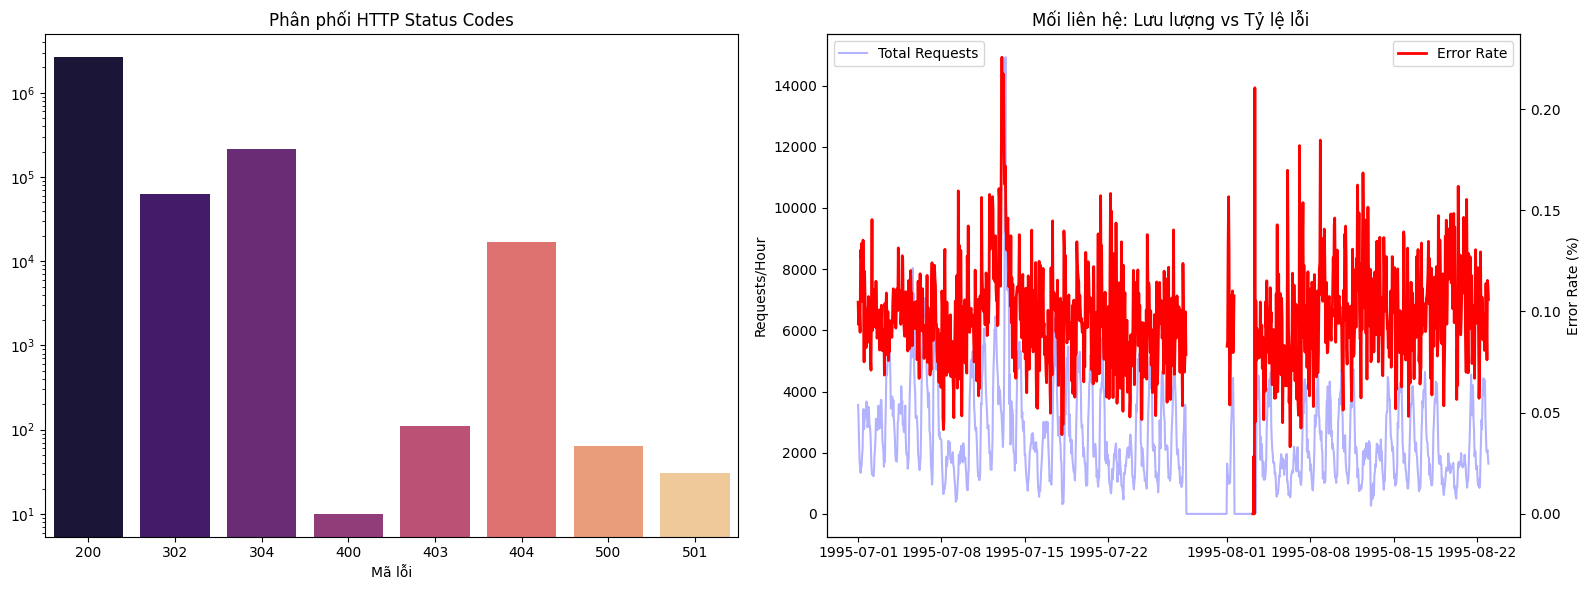

In [ ]:
status_counts = df_train['status'].value_counts()


fig, ax = plt.subplots(1, 2, figsize=(16, 6))


sns.barplot(x=status_counts.index, y=status_counts.values, ax=ax[0], palette="magma")
ax[0].set_title("Phân phối HTTP Status Codes")
ax[0].set_yscale("log")
ax[0].set_xlabel("Mã lỗi")



df_train['is_error'] = df_train['status'] != 200

hourly_stats = df_train.set_index('timestamp').resample('H').agg({
    'status': 'count',
    'is_error': 'sum'
})
hourly_stats['error_rate'] = hourly_stats['is_error'] / hourly_stats['status']

ax2 = ax[1].twinx()
ax[1].plot(hourly_stats.index, hourly_stats['status'], color='blue', alpha=0.3, label='Total Requests')
ax2.plot(hourly_stats.index, hourly_stats['error_rate'], color='red', label='Error Rate', linewidth=2)

ax[1].set_title("Mối liên hệ: Lưu lượng vs Tỷ lệ lỗi ")
ax[1].set_ylabel("Requests/Hour")
ax2.set_ylabel("Error Rate (%)")
ax[1].legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

/tmp/ipython-input-1902926759.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_forensics = df_train.set_index('timestamp').resample('H').agg({


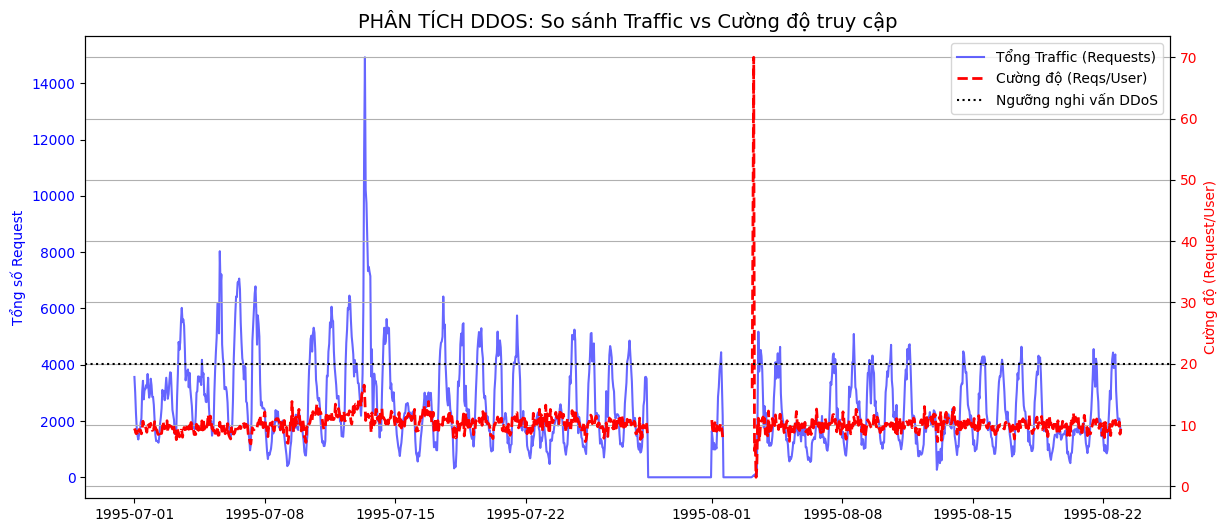

--- PHÂN TÍCH ĐIỂM SPIKE CAO NHẤT TẠI: 1995-07-13 09:00:00-04:00 ---
Tổng request tại đỉnh: 14926
Top 5 IPs hoạt động mạnh nhất lúc đó:
- vagrant.vf.mmc.com: 276 requests (1.85%)
- news.ti.com: 133 requests (0.89%)
- msn_2_4.binc.net: 114 requests (0.76%)
- 148.139.32.56: 114 requests (0.76%)
- 163.206.89.4: 103 requests (0.69%)
=> KẾT LUẬN: KHÔNG PHẢI DDOS. Traffic phân tán đều.


In [ ]:

df_forensics = df_train.set_index('timestamp').resample('H').agg({
    'request_src': ['count', 'nunique']
})
df_forensics.columns = ['total_reqs', 'unique_users']


df_forensics['intensity'] = df_forensics['total_reqs'] / df_forensics['unique_users']


fig, ax1 = plt.subplots(figsize=(14, 6))


ax1.plot(df_forensics.index, df_forensics['total_reqs'], color='blue', alpha=0.6, label='Tổng Traffic (Requests)')
ax1.set_ylabel('Tổng số Request', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')


ax2 = ax1.twinx()
ax2.plot(df_forensics.index, df_forensics['intensity'], color='red', linewidth=2, linestyle='--', label='Cường độ (Reqs/User)')
ax2.set_ylabel('Cường độ (Request/User)', color='red')
ax2.tick_params(axis='y', labelcolor='red')


ax2.axhline(20, color='black', linestyle=':', label='Ngưỡng nghi vấn DDoS')

plt.title('PHÂN TÍCH DDOS: So sánh Traffic vs Cường độ truy cập', fontsize=14)
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.grid(True)
plt.show()


peak_time = df_forensics['total_reqs'].idxmax()
print(f"--- PHÂN TÍCH ĐIỂM SPIKE CAO NHẤT TẠI: {peak_time} ---")


peak_data = df_train[
    (df_train['timestamp'] >= peak_time) &
    (df_train['timestamp'] < peak_time + pd.Timedelta(hours=1))
]


top_ips_at_peak = peak_data['request_src'].value_counts().head(5)
total_reqs_at_peak = len(peak_data)

print(f"Tổng request tại đỉnh: {total_reqs_at_peak}")
print("Top 5 IPs hoạt động mạnh nhất lúc đó:")
for ip, count in top_ips_at_peak.items():
    percent = (count / total_reqs_at_peak) * 100
    print(f"- {ip}: {count} requests ({percent:.2f}%)")

if top_ips_at_peak.iloc[0] / total_reqs_at_peak > 0.3:
    print("=> KẾT LUẬN: CÓ DẤU HIỆU DDOS (1 IP chiếm >30% traffic).")
else:
    print("=> KẾT LUẬN: KHÔNG PHẢI DDOS. Traffic phân tán đều.")

/tmp/ipython-input-3833142444.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_hosts.index, x=top_hosts.values, palette="viridis")


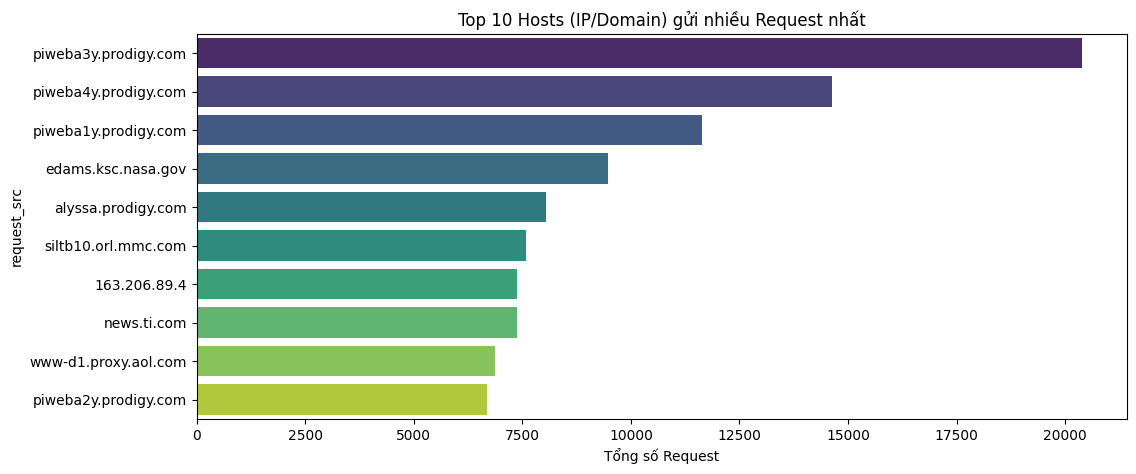

Thống kê về Host lớn nhất (piweba3y.prodigy.com):
- Tổng requests: 20402
- Tổng bytes tải: 465.12 MB
- Các file hay tải: 
dest_path
/images/NASA-logosmall.gif                         1153
/images/KSC-logosmall.gif                          1127
/shuttle/missions/sts-71/sts-71-patch-small.gif    1125
Name: count, dtype: int64


In [ ]:

top_hosts = df_train['request_src'].value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(y=top_hosts.index, x=top_hosts.values, palette="viridis")
plt.title("Top 10 Hosts (IP/Domain) gửi nhiều Request nhất")
plt.xlabel("Tổng số Request")
plt.show()

top_1_host = top_hosts.index[0]
host_data = df_train[df_train['request_src'] == top_1_host]
print(f"Thống kê về Host lớn nhất ({top_1_host}):")
print(f"- Tổng requests: {len(host_data)}")
print(f"- Tổng bytes tải: {host_data['bytes'].sum() / 1024 / 1024:.2f} MB")
print(f"- Các file hay tải: \n{host_data['dest_path'].value_counts().head(3)}")

/tmp/ipython-input-3493161360.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_features = df_train.set_index('timestamp').resample('H').agg({


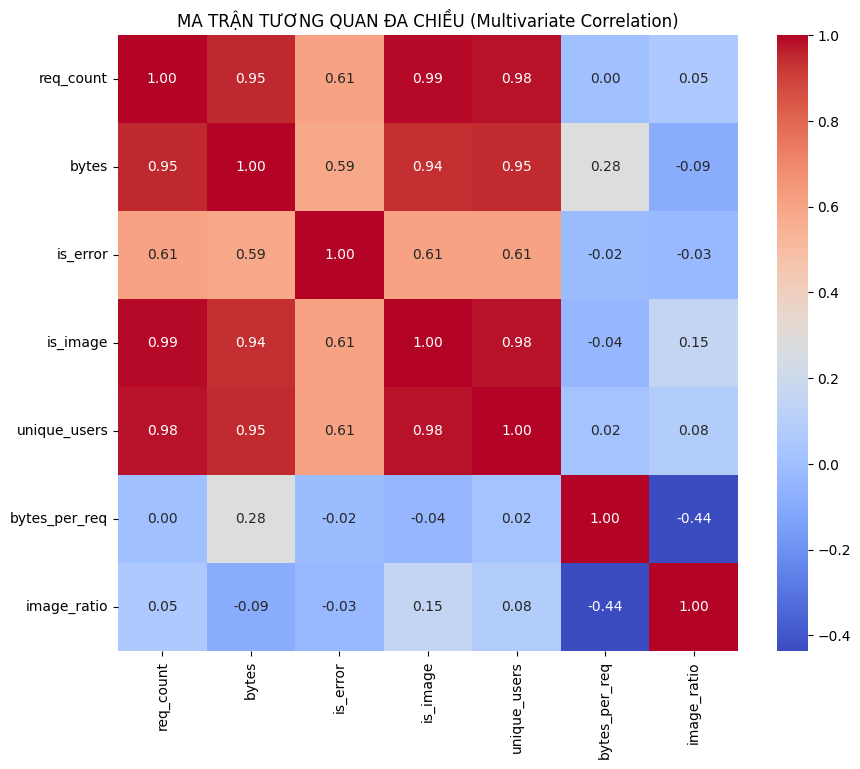

In [ ]:
df_train['is_image'] = df_train['dest_path'].str.contains(r'\.gif|\.jpg|\.jpeg', case=False, regex=True).astype(int)
df_train['is_error'] = (df_train['status'] >= 400).astype(int)


df_features = df_train.set_index('timestamp').resample('H').agg({
    'status': 'count',
    'bytes': 'sum',
    'is_error': 'sum',
    'is_image': 'sum',
    'request_src': 'nunique'
}).rename(columns={'status': 'req_count', 'request_src': 'unique_users'})


df_features['bytes_per_req'] = df_features['bytes'] / df_features['req_count']
df_features['image_ratio'] = df_features['is_image'] / df_features['req_count']


plt.figure(figsize=(10, 8))
sns.heatmap(df_features.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("MA TRẬN TƯƠNG QUAN ĐA CHIỀU (Multivariate Correlation)")
plt.show()